# Multi-sample conparison

## Notes

This notebook demonstrates ONTraC's ability to create consistent spatial trajectories across multiple samples/slices.

- We assume that you have installed ONTraC according to the [Installation Tutorial](../installation.md) and open this notebook using installed Python kernel (Python 3.11 (ONTraC)).
- The ONTraC running process could be found at our [example tutorial](../examples/Running_ONTraC_on_merfish_dataset.ipynb)

## Load Modules

In [1]:
import os
import sys
import requests
import zipfile

In [2]:
import numpy as np
import pandas as pd

In [3]:
from scipy.stats import spearmanr

In [4]:
import matplotlib as mpl
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'Arial'
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
from ONTraC.analysis.data import AnaData

In [6]:
import session_info

## Download Pre-processed Data

In [7]:
import requests

# URL of the file
url = "https://zenodo.org/records/15571644/files/MERFISH_data.zip"

# Local file path to save the file
file_path = "./MERFISH_data.zip"

try:
    # Send a GET request to the URL
    response = requests.get(url)
    response.raise_for_status()  # Check if the request was successful

    # Write the content to the file
    with open(file_path, "wb") as file:
        file.write(response.content)

    print(f"File downloaded and saved to {file_path}")
except requests.exceptions.RequestException as e:
    print(f"An error occurred: {e}")



File downloaded and saved to ./MERFISH_data.zip


In [8]:
import zipfile

# Path to the zip file
zip_file_path = "MERFISH_data.zip"

# Directory where files will be extracted
extract_to_path = "./"

try:
    # Open the zip file
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        # Extract all files to the specified directory
        zip_ref.extractall(extract_to_path)

    print(f"Files extracted to '{extract_to_path}'")
except zipfile.BadZipFile:
    print("The file is not a valid zip file.")

Files extracted to './'


In [9]:
from optparse import Values

options = Values()
options.NN_dir = 'MERFISH_data/ONTraC_output/merfish_cortex_base_NN/'
options.GNN_dir = 'MERFISH_data/ONTraC_output/merfish_cortex_base_GNN/'
options.NT_dir = 'MERFISH_data/ONTraC_output/merfish_cortex_base_NT/'
options.log = 'MERFISH_data/ONTraC_run_log/merfish_cortex_base.log'
options.reverse = True  # Set it to False if you don't want reverse NT score
options.output = None  # We save the output figure by our self here
ana_data = AnaData(options)

In [10]:
raw_meta_data = pd.read_csv('MERFISH_data/preprocessing/merfish_meta.csv', index_col=0)
raw_meta_data.head()

,sample_id,slice_id,class_label,subclass,label,x,y,cortical_depth,extra_annot,leiden_res_10.00,leiden_res_30.00
index,,,,,,,,,,,
10000143038275111136124942858811168393,mouse2_sample4,mouse2_slice31,Other,Astro,Astro_1,4738.402723,3075.604074,888.114748,Astro,0,245
100001798412490480358118871918100400402,mouse2_sample5,mouse2_slice160,Other,Endo,Endo,-3965.470904,1451.943297,1449.123485,Endo,8,206
100006878605830627922364612565348097824,mouse2_sample6,mouse2_slice109,Other,SMC,SMC,805.848948,1215.458623,22.943763,SMC,39,174
100007228202835962319771548915451072492,mouse1_sample2,mouse1_slice71,Other,Endo,Endo,1347.655448,-3589.803355,1086.621925,Endo,10,177
100009332472089331948140672873134747603,mouse2_sample5,mouse2_slice219,Glutamatergic,L2/3 IT,L23_IT_3,-3584.216904,-1883.214455,308.178627,L2/3 IT,59,61


Cortical depth is the distance to the closest VLMC cells at the boundary. Please refer to the [preprocessing code](https://github.com/gyuanlab/ONTraC_paper/blob/master/MERFISH_motor_cortex_data/preprocessing/Py_preprocessing.ipynb) for details.

## Settings

In [11]:
selected_samples = ['mouse1_slice301', 'mouse2_slice139', 'mouse1_slice112', 'mouse2_slice109']
selected_cell_types = ["VLMC", 'L2/3 IT', 'L4/5 IT', 'L5 IT', 'L6 IT', 'Oligo']
seletec_cells = np.array([
    [
        '222677948836547691157583317302948041119',
        '270983339084936120425898242693492994322',
        '218407269296745845339619862860897282853',
    ],
    [
        '149213436288632577209153391820211062186',
        '297157500398332531962433018999455104924',
        '182109812168162263346685203576665566069',
    ],
    [
        '326096346689346684283319601332360643694',
        '327322487218929045309525150739577406930',
        '88387307250154251334932059809457815292',
    ],
    [
        '160549445236371175643985900685266177992',
        '148823420983778850480966339211038874267',
        '319485842879148352963942159911256185902',
    ],
])
selected_cell_colors = ['green','blue','cyan']


In [12]:
cmap = mpl.colormaps['Set1']

cell_types = ana_data.meta_data_df['Cell_Type'].unique().tolist()

my_pal = {"VLMC": cmap(0)}
my_pal.update({cell_type: cmap( 0.3 + 0.7 * (i - 1) / (len(selected_cell_types) - 1)) for i, cell_type in enumerate(selected_cell_types[1:])})
my_pal.update({cell_type: 'gray' for cell_type in cell_types if cell_type not in selected_cell_types})
my_pal

{'VLMC': (0.8941176470588236, 0.10196078431372549, 0.10980392156862745, 1.0),
 'L2/3 IT': (0.21568627450980393,
  0.49411764705882355,
  0.7215686274509804,
  1.0),
 'L4/5 IT': (0.30196078431372547, 0.6862745098039216, 0.2901960784313726, 1.0),
 'L5 IT': (0.596078431372549, 0.3058823529411765, 0.6392156862745098, 1.0),
 'L6 IT': (1.0, 1.0, 0.2, 1.0),
 'Oligo': (0.6509803921568628, 0.33725490196078434, 0.1568627450980392, 1.0),
 'Astro': 'gray',
 'Endo': 'gray',
 'SMC': 'gray',
 'L6 CT': 'gray',
 'Peri': 'gray',
 'L5 ET': 'gray',
 'Micro': 'gray',
 'Sst': 'gray',
 'Sncg': 'gray',
 'L6 IT Car3': 'gray',
 'Vip': 'gray',
 'PVM': 'gray',
 'L5/6 NP': 'gray',
 'Pvalb': 'gray',
 'OPC': 'gray',
 'other': 'gray',
 'L6b': 'gray',
 'Lamp5': 'gray'}

## Spatial Cell Type Distribution of Selected Samples

In [13]:
ana_data.meta_data_df.head()

,Sample,Cell_Type,x,y,Embedding_1,Embedding_2
Cell_ID,,,,,,
10000143038275111136124942858811168393,mouse2_slice31,Astro,4738.402723,3075.604074,2.155048,7.127876
100001798412490480358118871918100400402,mouse2_slice160,Endo,-3965.470904,1451.943297,5.790349,11.770921
100006878605830627922364612565348097824,mouse2_slice109,SMC,805.848948,1215.458623,8.902917,11.969505
100007228202835962319771548915451072492,mouse1_slice71,Endo,1347.655448,-3589.803355,5.535499,12.307374
100009332472089331948140672873134747603,mouse2_slice219,L2/3 IT,-3584.216904,-1883.214455,0.248998,16.258825


In [14]:
samples = ana_data.meta_data_df['Sample'].unique().tolist()
cell_types = ana_data.meta_data_df['Cell_Type'].unique().tolist()

In [15]:
data_df = ana_data.meta_data_df.loc[ana_data.meta_data_df['Sample'].isin(selected_samples)]  # selected samples for visualization
plot_data_df = data_df.copy()
plot_data_df.loc[plot_data_df['Sample']=='mouse2_slice139','x'] = data_df.loc[plot_data_df['Sample']=='mouse2_slice139','y']
plot_data_df.loc[plot_data_df['Sample']=='mouse2_slice139','y'] = data_df.loc[plot_data_df['Sample']=='mouse2_slice139','x']
plot_data_df.loc[:,'color'] = [my_pal[x] for x in plot_data_df['Cell_Type']]  # set colors
plot_data_df.loc[:,'size'] = [3 if x in selected_cell_types else 1 for x in plot_data_df['Cell_Type']]  # set size
plot_data_df.head()

,Sample,Cell_Type,x,y,Embedding_1,Embedding_2,color,size
Cell_ID,,,,,,,,
100006878605830627922364612565348097824,mouse2_slice109,SMC,805.848948,1215.458623,8.902917,11.969505,gray,1
100048801985494957069277355580243213453,mouse1_slice112,Astro,3729.231400,3758.088746,1.808534,8.124959,gray,1
10005934872894141098004245916130294941,mouse1_slice112,Endo,4497.223901,2174.526495,6.205052,9.715218,gray,1
100067895848056932461806120622152951315,mouse2_slice109,Micro,-298.459511,3240.207594,7.163212,5.260627,gray,1
100081856573013143402587078828340349285,mouse2_slice139,Astro,-3127.453806,3438.259872,3.144731,8.946029,gray,1


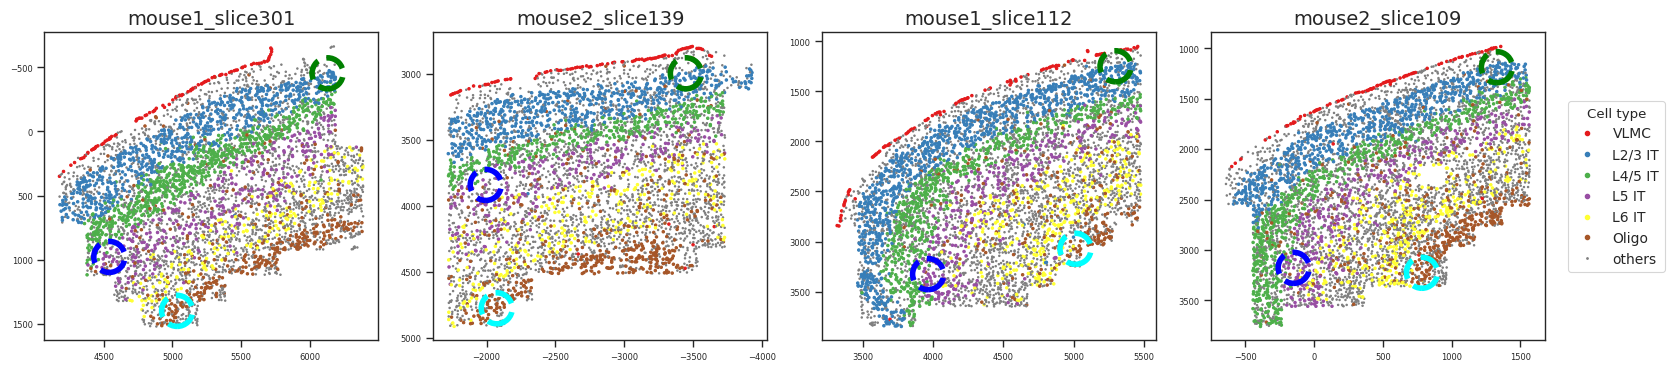

In [16]:
with sns.axes_style('white', rc={
        'xtick.bottom': True,
        'ytick.left': True
}), sns.plotting_context('paper',
                         rc={
                             'axes.titlesize': 14,
                             'axes.labelsize': 8,
                             'xtick.labelsize': 6,
                             'ytick.labelsize': 6,
                             'legend.fontsize': 10
                         }):
    fig = plt.figure(figsize=(20.5, 4))
    axes = []
    gs = gridspec.GridSpec(nrows=1, ncols=5, width_ratios=[5,5,5,5,.5])
    
    # samples
    for index, sample in enumerate(selected_samples):
        sample_data_df = plot_data_df[plot_data_df['Sample']==sample]
        axes.append(fig.add_subplot(gs[index]))
        axes[index].scatter(sample_data_df['x'], sample_data_df['y'], c=sample_data_df['color'], s=sample_data_df['size'])
        axes[index].scatter(
            plot_data_df.loc[seletec_cells[index]]['x'],
            plot_data_df.loc[seletec_cells[index]]['y'],
            c='None',
            edgecolors=selected_cell_colors,
            linewidths=4,
            linestyle='--',
            s=500,
        )
        axes[index].set_title(sample)
        
    axes[0].invert_yaxis()
    axes[1].invert_xaxis()
    axes[1].invert_yaxis()
    axes[2].invert_yaxis()
    axes[3].invert_yaxis()
    
    # legend
    axes.append(fig.add_subplot(gs[-1]))
    legend_elements = [Line2D([0], [0], marker='.', color=my_pal[ct], label=ct, linestyle='None',
                      markerfacecolor=None, markersize=6) for ct in selected_cell_types] + [
        Line2D([0], [0], marker='.', color='gray', label='others', linestyle='None', markerfacecolor=None, markersize=2)]
    axes[-1].legend(handles=legend_elements, loc='center', ncol=1, title="Cell type")
    axes[-1].axis('off')
    
    fig.savefig('Multisamples_spatial_cell_types.pdf', transparent=True)
    fig.savefig('Multisamples_spatial_cell_types.png', dpi=300)

The four slices from different mice exhibit similar structures. We selected three cells from each slice that share a similar microenvironment (cell type composition).


## Spatial NT Score Distribution of Selected Samples

In [17]:
data_df = ana_data.meta_data_df.loc[ana_data.meta_data_df['Sample'].isin(selected_samples)].join(ana_data.NT_score[['Cell_NTScore']])  # selected samples for visualization
plot_data_df = data_df.copy()
plot_data_df.loc[plot_data_df['Sample']=='mouse2_slice139','x'] = data_df.loc[plot_data_df['Sample']=='mouse2_slice139','y']
plot_data_df.loc[plot_data_df['Sample']=='mouse2_slice139','y'] = data_df.loc[plot_data_df['Sample']=='mouse2_slice139','x']
plot_data_df.loc[:,'color'] = 1 - plot_data_df['Cell_NTScore'] if options.reverse else plot_data_df['Cell_NTScore']
plot_data_df.head()

,Sample,Cell_Type,x,y,Embedding_1,Embedding_2,Cell_NTScore,color
Cell_ID,,,,,,,,
100006878605830627922364612565348097824,mouse2_slice109,SMC,805.848948,1215.458623,8.902917,11.969505,0.996727,0.003273
100048801985494957069277355580243213453,mouse1_slice112,Astro,3729.231400,3758.088746,1.808534,8.124959,0.776955,0.223045
10005934872894141098004245916130294941,mouse1_slice112,Endo,4497.223901,2174.526495,6.205052,9.715218,0.436736,0.563264
100067895848056932461806120622152951315,mouse2_slice109,Micro,-298.459511,3240.207594,7.163212,5.260627,0.579384,0.420616
100081856573013143402587078828340349285,mouse2_slice139,Astro,-3127.453806,3438.259872,3.144731,8.946029,0.554079,0.445921


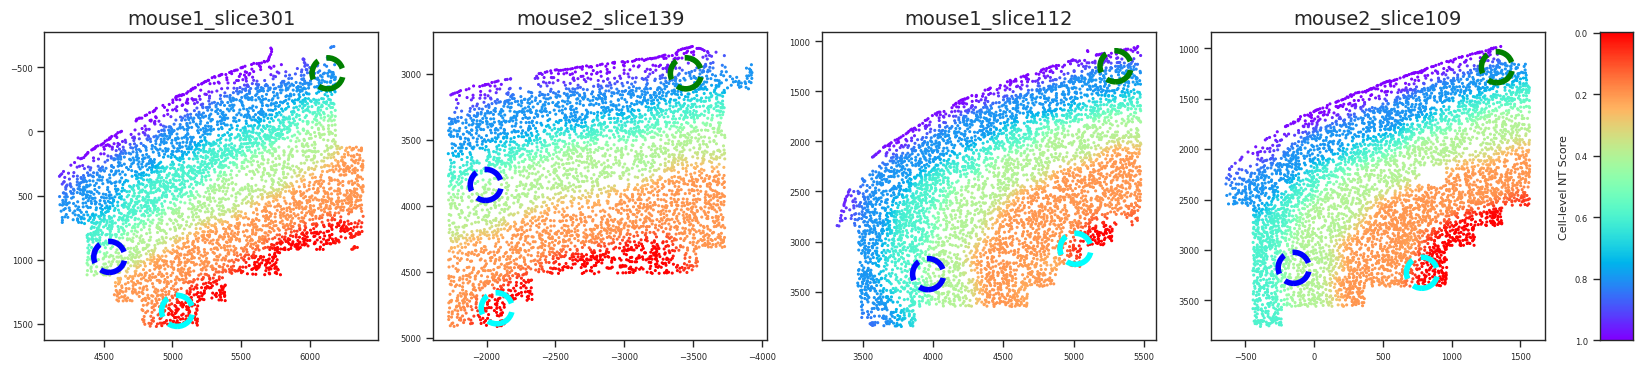

In [18]:
with sns.axes_style('white', rc={
        'xtick.bottom': True,
        'ytick.left': True
}), sns.plotting_context('paper',
                         rc={
                             'axes.titlesize': 14,
                             'axes.labelsize': 8,
                             'xtick.labelsize': 6,
                             'ytick.labelsize': 6,
                             'legend.fontsize': 10
                         }):
    fig = plt.figure(figsize=(20.5, 4))
    axes = []
    gs = gridspec.GridSpec(nrows=1, ncols=5, width_ratios=[5,5,5,5,.5])
    
    # samples
    for index, sample in enumerate(selected_samples):
        sample_data_df = plot_data_df[plot_data_df['Sample']==sample]
        axes.append(fig.add_subplot(gs[index]))
        axes[index].scatter(sample_data_df['x'],
                            sample_data_df['y'],
                            c=sample_data_df['color'],
                            cmap='rainbow',
                            vmin=0,
                            vmax=1,
                            s=2,)
        axes[index].scatter(
            plot_data_df.loc[seletec_cells[index]]['x'],
            plot_data_df.loc[seletec_cells[index]]['y'],
            c='None',
            edgecolors=selected_cell_colors,
            linewidths=4,
            linestyle='--',
            s=500,
        )
        axes[index].set_title(sample)
        
    axes[0].invert_yaxis()
    axes[1].invert_xaxis()
    axes[1].invert_yaxis()
    axes[2].invert_yaxis()
    axes[3].invert_yaxis()
    
    # legend
    axes.append(fig.add_subplot(gs[-1]))
    gradient = np.linspace(1, 0, 1000).reshape(-1, 1)
    axes[-1].imshow(gradient, aspect='auto', cmap='rainbow')
    axes[-1].set_xticks([])
    axes[-1].set_yticks(np.linspace(0, 1000, 6))
    axes[-1].set_yticklabels([f'{x:.01f}' for x in np.linspace(0, 1, 6)])
    axes[-1].set_ylabel('Cell-level NT Score')
    
    fig.savefig('Multisamples_spatial_NTScore.pdf', transparent=True)
    fig.savefig('Multisamples_spatial_NTScore.png', dpi=300)

ONTraC generates consistent spatial trajectories (NT score) across multiple slices.

## Cell Type Composition of Niches Anchored to Selected Cells

/tmp/ipykernel_836317/3960292759.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_ctc_df.loc[:,'Sample'] = selected_samples
/tmp/ipykernel_836317/3960292759.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
/tmp/ipykernel_836317/3960292759.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_ctc_df.loc[:,'Sample'] = selected_samples
/tmp/i

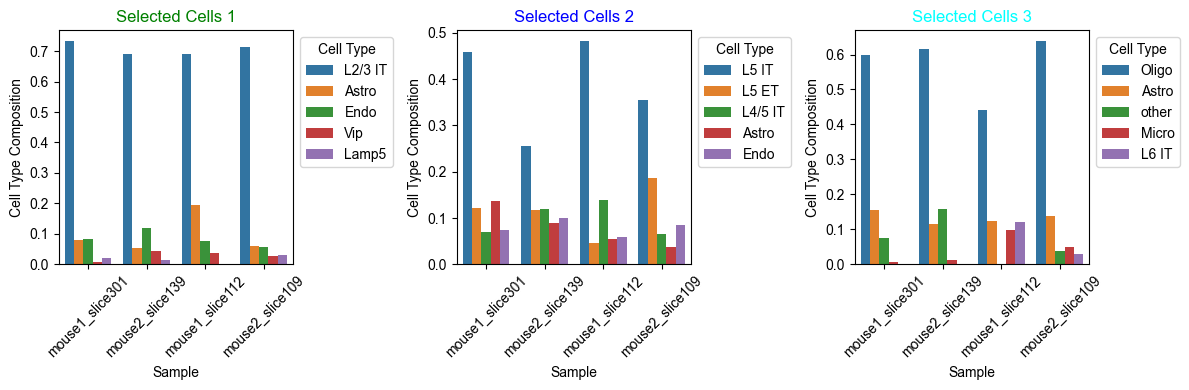

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i in range(3):
    
    raw_ctc_df = ana_data.cell_type_composition.loc[seletec_cells[:,i]]
    
    selected_ctc_df = raw_ctc_df[raw_ctc_df.sum().sort_values(ascending=False)[:5].index]
    selected_ctc_df.loc[:,'Sample'] = selected_samples

    plot_data_df = selected_ctc_df.melt(id_vars=['Sample'],value_vars=selected_ctc_df.columns.tolist()[:5], var_name='Cell Type', value_name='Cell Type Composition',ignore_index=True)
    
    sns.barplot(data=plot_data_df,
                x='Sample',
                y='Cell Type Composition',
                hue='Cell Type',
                ax=axes[i])
    axes[i].legend(loc='upper left', bbox_to_anchor=(1,1), title='Cell Type')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
    axes[i].set_title(f'Selected Cells {i+1}', c=selected_cell_colors[i])
    
fig.tight_layout()
fig.savefig('Multisamples_cell_type_composition_of_selected_cells.pdf', transparent=True)
fig.savefig('Multisamples_cell_type_composition_of_selected_cells.png', dpi=300)

Niches anchored to seletec cells exhibit similar cell type compositions.

## Spatially Localized Cell Types Share Similar NT Scores across Samples

In [20]:
data_df = ana_data.meta_data_df.join(ana_data.NT_score[['Cell_NTScore']]).join(raw_meta_data[['cortical_depth']])
data_df.loc[:,'Cell_NTScore'] = 1 - data_df['Cell_NTScore'] if options.reverse else data_df['Cell_NTScore']
data_df.loc[:,'norm_cortical_depth'] = data_df.loc[:,'cortical_depth'].values / data_df.loc[:,'cortical_depth'].values.max()
data_df.head()

,Sample,Cell_Type,x,y,Embedding_1,Embedding_2,Cell_NTScore,cortical_depth,norm_cortical_depth
Cell_ID,,,,,,,,,
10000143038275111136124942858811168393,mouse2_slice31,Astro,4738.402723,3075.604074,2.155048,7.127876,0.601854,888.114748,0.374428
100001798412490480358118871918100400402,mouse2_slice160,Endo,-3965.470904,1451.943297,5.790349,11.770921,0.771806,1449.123485,0.610949
100006878605830627922364612565348097824,mouse2_slice109,SMC,805.848948,1215.458623,8.902917,11.969505,0.003273,22.943763,0.009673
100007228202835962319771548915451072492,mouse1_slice71,Endo,1347.655448,-3589.803355,5.535499,12.307374,0.785716,1086.621925,0.458118
100009332472089331948140672873134747603,mouse2_slice219,L2/3 IT,-3584.216904,-1883.214455,0.248998,16.258825,0.200618,308.178627,0.129928


In [21]:
selected_cell_types_ = selected_cell_types[:]
selected_cell_types_.remove('Oligo')
plot_data_df = data_df[(data_df['Sample'].isin(selected_samples)) & (data_df['Cell_Type'].isin(selected_cell_types_))][['Sample','Cell_Type','Cell_NTScore']]
plot_data_df['Sample'] = pd.Categorical(plot_data_df['Sample'], categories=selected_samples)  # remove unused samples
plot_data_df['Cell_Type'] = pd.Categorical(plot_data_df['Cell_Type'], categories=selected_cell_types_)  # remove unused cell types
plot_data_df.head()


,Sample,Cell_Type,Cell_NTScore
Cell_ID,,,
100106378211286780818879112257146169937,mouse1_slice112,L2/3 IT,0.199834
10013848917901580372984707123288841246,mouse1_slice301,L2/3 IT,0.306513
100160195205774348243612139282662971606,mouse1_slice112,L4/5 IT,0.459411
100179412288981831083890706042055546088,mouse1_slice112,L4/5 IT,0.334687
100203393073383662058607743517170536086,mouse1_slice301,L4/5 IT,0.378311


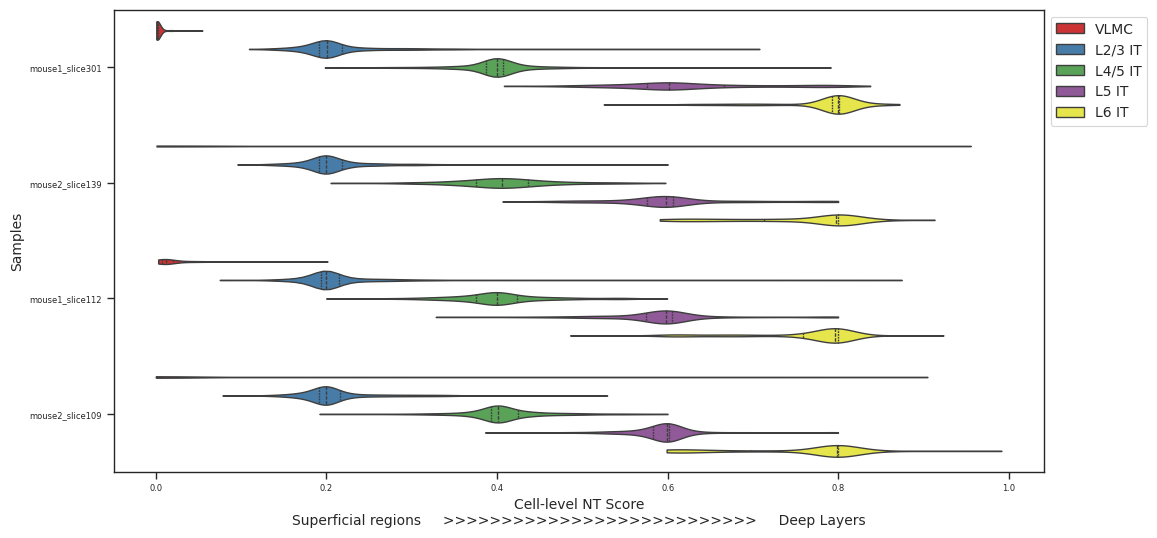

In [22]:
with sns.axes_style('white', rc={
        'xtick.bottom': True,
        'ytick.left': True
}), sns.plotting_context('paper',
                         rc={
                             'axes.titlesize': 14,
                             'axes.labelsize': 10,
                             'xtick.labelsize': 6,
                             'ytick.labelsize': 6,
                             'legend.fontsize': 10
                         }):
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.violinplot(
        data=plot_data_df,
        x='Cell_NTScore',
        y='Sample',
        hue='Cell_Type',
        palette=my_pal,
        inner='quart',
        cut=0,
        ax=ax
    )
    ax.legend(loc='upper left', bbox_to_anchor=(1,1))
    ax.set_xlabel('Cell-level NT Score\nSuperficial regions     >>>>>>>>>>>>>>>>>>>>>>>>>>>     Deep Layers')
    ax.set_ylabel('Samples')
    fig.savefig('Multisamples_violin_selected_ct_in_selected_samples_Cell_NTScore.pdf', transparent=True)
    fig.savefig('Multisamples_violin_selected_ct_in_selected_samples_Cell_NTScore.png', dpi=300)

## Session Info

In [23]:
session_info.show()